<a href="https://colab.research.google.com/github/Aaditya1412/breast_cancer_detection/blob/main/Breast_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

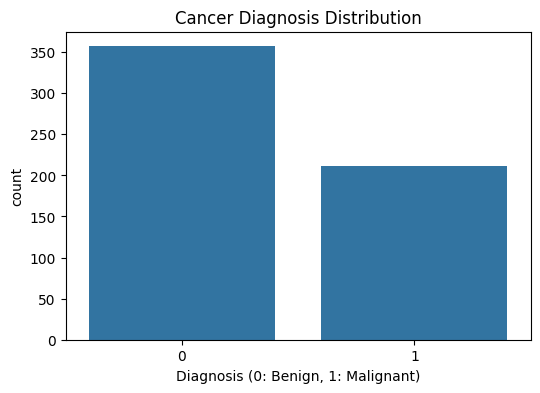

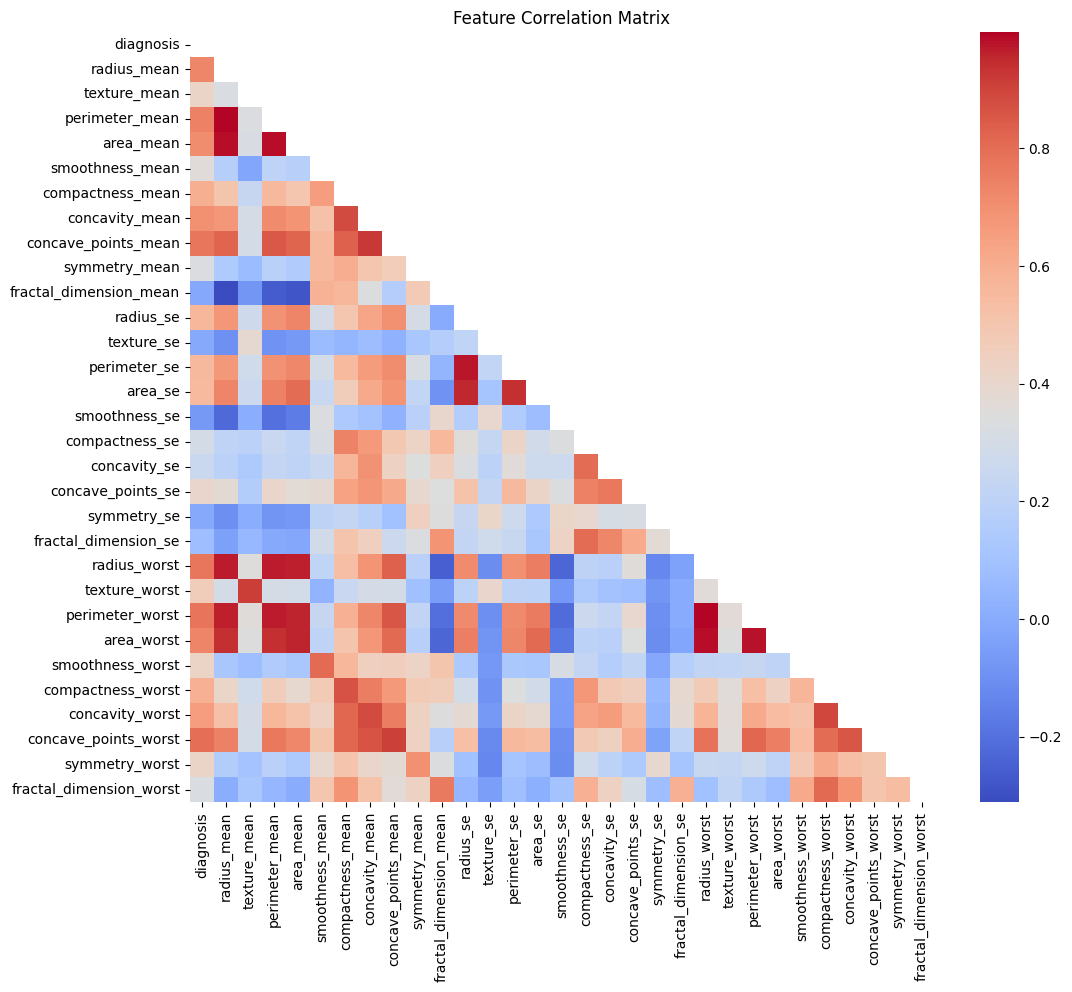

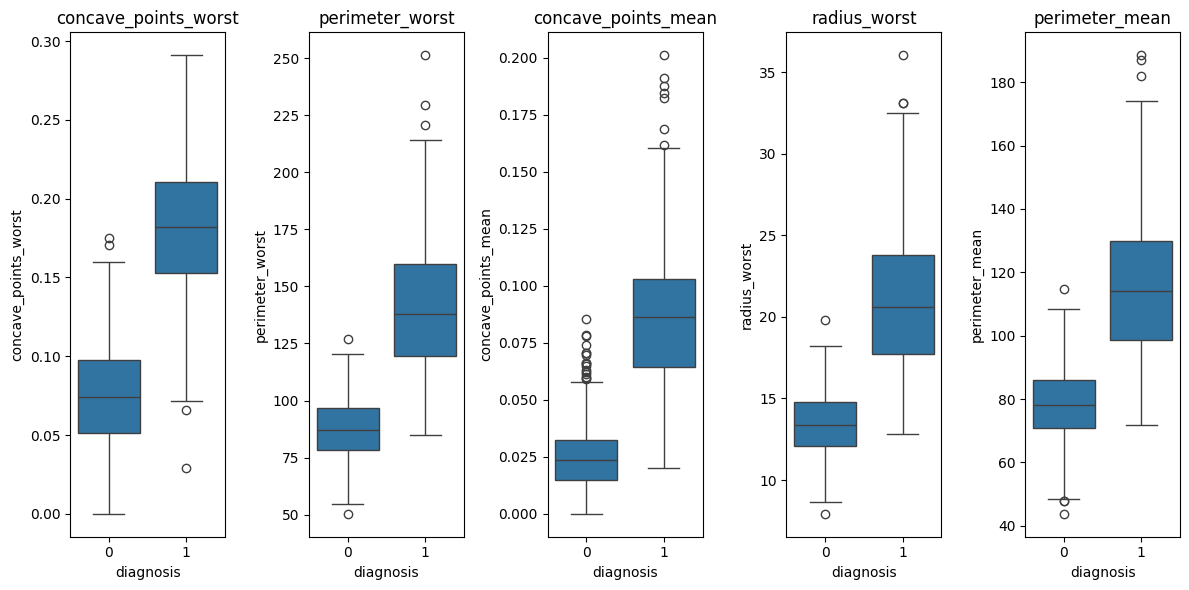

Logistic Regression Test Acc: 0.9649 | CV Acc: 0.9807
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

KNN Test Acc: 0.9561 | CV Acc: 0.9649
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

SVM Test Acc: 0.9737 | CV Acc: 0.9736
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       11

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
column_names = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se", "compactness_se",
    "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]
data = pd.read_csv(url, header=None, names=column_names)
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})
data = data.drop('id', axis=1)
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Cancer Diagnosis Distribution')
plt.xlabel('Diagnosis (0: Benign, 1: Malignant)')
plt.show()
plt.figure(figsize=(12, 10))
corr = data.corr()
mask = np.triu(corr)
sns.heatmap(corr, mask=mask, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()
corr_target = abs(corr['diagnosis']).sort_values(ascending=False)
top_features = corr_target[1:6].index
plt.figure(figsize=(12, 6))
for i, feature in enumerate(top_features):
    plt.subplot(1, 5, i+1)
    sns.boxplot(x='diagnosis', y=feature, data=data)
    plt.title(feature)
plt.tight_layout()
plt.show()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
    print(f"{name} Test Acc: {acc:.4f} | CV Acc: {cv:.4f}")
    print(classification_report(y_test, y_pred))
    return model, acc, cv
results = {}
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
for name, model in models.items():
    m, acc, cv = evaluate_model(model, name)
    results[name] = (m, acc, cv)
best_name = max(results, key=lambda k: results[k][2])
best_model = results[best_name][0]
if best_name == "Logistic Regression":
    param_grid = {'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}
    base_model = LogisticRegression(random_state=42, max_iter=1000)
elif best_name == "KNN":
    param_grid = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    base_model = KNeighborsClassifier()
elif best_name == "SVM":
    param_grid = {'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1], 'kernel': ['rbf', 'linear']}
    base_model = SVC(probability=True, random_state=42)
else:
    param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10]}
    base_model = RandomForestClassifier(random_state=42)
grid = GridSearchCV(base_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
tuned_model = grid.best_estimator_
print(f"\nTuned {best_name} Results:")
evaluate_model(tuned_model, f"Tuned {best_name}")
if best_name == "Random Forest":
    fi = pd.Series(tuned_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\nTop 10 Important Features:\n", fi.head(10))
    fi.head(15).plot(kind='barh')
    plt.title('Feature Importance')
    plt.show()
with open('breast_cancer_model.pkl', 'wb') as f:
    pickle.dump(tuned_model, f)
with open('breast_cancer_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
def predict_cancer(model, scaler, input_data):
    arr = np.array(input_data).reshape(1, -1)
    arr_scaled = scaler.transform(arr)
    pred = model.predict(arr_scaled)[0]
    prob = model.predict_proba(arr_scaled)[0][1] if hasattr(model, "predict_proba") else None
    return 'Malignant' if pred == 1 else 'Benign', prob
sample = X_test[0].reshape(1, -1)
result, probability = predict_cancer(tuned_model, scaler, sample)
print(f"Prediction: {result}, Probability: {probability:.4f}" if probability else f"Prediction: {result}")


In [ ]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')